In [18]:
import pandas as pd
from IPython.display import Audio, display
import soundfile as sf
from pydub import AudioSegment
import numpy as np
import os, gc , time, json
from io import BytesIO


AudioPATH= "./audio"
RefVoicePATH = "./audio/ref_voice/warm_reporter_well_paced_steady_friendly.mp3"
RefVoicePATHWav = "./audio/ref_voice/warm_reporter_well_paced_steady_friendly.wav"
TokenModel="Qwen/Qwen3-TTS-Tokenizer-12Hz"
ModelId1="Qwen/Qwen3-TTS-12Hz-1.7B-Base"
ModelId2="Qwen/Qwen3-TTS-12Hz-0.6B-Base"
ModelId3="Qwen3-TTS-12Hz-0.6B-CustomVoice"

In [19]:
# !pip install pydub

In [20]:
## Convert refvoice  mp3 file to wave file

In [21]:
from pydub import AudioSegment

# Define the paths for the input MP3 and output WAV files
src = RefVoicePATH
dst = RefVoicePATHWav

# Convert the MP3 file to a WAV file
try:
    sound = AudioSegment.from_mp3(src)
    sound.export(dst, format="wav")
    print(f"Successfully converted {src} to {dst}")
except Exception as e:
    print(f"An error occurred: {e}")

An error occurred: [Errno 2] No such file or directory: './audio/ref_voice/warm_reporter_well_paced_steady_friendly.mp3'


## Load Cantonese dataset, download from huggingface : a cleaned verison from AlienKevin/mixed_cantonese_and_english_speech:
https://huggingface.co/datasets/AlienKevin/mixed_cantonese_and_english_speech

In [22]:
df = pd.read_parquet("train-00000-of-00001.parquet")

In [23]:
df.columns

Index(['audio', 'sentence', 'topic'], dtype='object')

In [24]:
df

,audio,sentence,topic
0,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,你知唔知今日嘅temperature會落到低至10度，一定要著厚d嘅clothes啊！,天氣
1,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,我check咗天氣app，佢話今日會有thunderstorm，最好唔好去戶外行嘅。,天氣
2,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,飛機已經被grounded喇，因為typhoon signal已經升到No.8嚟啦。,天氣
3,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,周圍都有well-developed霧，嚴重limit我哋嘅visibility，開車嘅時候...,天氣
4,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,Forecast話晚上嘅weather會變得好cold，會降到freezing point，...,天氣
...,...,...,...
14012,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,雖然香港天氣好hot，但我哋可以想下use less air con，改用風扇。,环境
14013,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,Buy local 嘅商品都可以減少carbon footprint，唔再郵寄長途嘅貨品。,环境
14014,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,用solar power同wind power都唔錯，我哋要追求sustainable嘅生活方式。,环境
14015,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,"Reduce, Reuse, Recycle 呢個三R原則喺日常生活中實踐，即係好好嘅典範。",环境


In [25]:
df["audio"][0]

{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x00\x00\x00\x0f\x00\x00\x03Lavf58.76.100\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xff\xf3X\xc0\x00\x00\x00\x00\x00\x00\x00\x00\x00Info\x00\x00\x00\x0f\x00\x00\x00\xe4\x00\x00`\xe4\x00\x05\x07\t\r\x0f\x11\x13\x17\x19\x1b\x1e!#%(+-0257:<?BDFILNPSVX[^`behjlprtvz|~\x82\x84\x86\x88\x8c\x8e\x90\x92\x96\x98\x9a\x9d\xa0\xa2\xa4\xa7\xaa\xac\xaf\xb1\xb4\xb6\xb9\xbc\xbe\xc1\xc3\xc6\xc8\xcb\xcd\xd0\xd2\xd5\xd7\xda\xdd\xdf\xe1\xe4\xe7\xe9\xeb\xef\xf1\xf3\xf5\xf9\xfb\xfd\x00\x00\x00\x00Lavc58.13\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00$\x04\x15\x00\x00\x00\x00\x00\x00`\xe4\xc0zi\x0b\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xff\xf38\xc4\x00\x00\x00\x03H\x00\x00\x00\x00LAME3.100UUUUUUUUUUUUUUUUUUUUULAME3.100UUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUU\xff\xf38\xc4_\x00\x00\x03H\x00\x00\x00\x00UUUUUUUUUUUUUUUUUUUUUUUUUUUUUULAME3.100UUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUUU\xff\xf38\xc4\xa0\x00\x00\x03H\x00\x00\x00\x00U

In [26]:
df["topic"].unique()

array(['天氣', '食物', '旅遊', '娛樂', '體育', '本地時事', '購物', '學習', '工作', '健康同健身',
       '宠物', '科技同新闻', '电影同电视剧', '音乐同艺术', '爱好同兴趣', '历史同文学', '社交媒体同网络文化',
       '环境'], dtype=object)

## Checking the Audio and Text label

In [27]:
def playAudio(raw):
    display(Audio(raw))

In [28]:
index = 3

playAudio(df["audio"][index]["bytes"]) 
print(f"Index : {index}")
print(f"Text : {df["sentence"][index]}")
print(f"File: {df["audio"][index]["path"]}")

Index : 3
Text : 周圍都有well-developed霧，嚴重limit我哋嘅visibility，開車嘅時候要小心啲！
File: 1_4.mp3


## Prepare Audio File for Hong Kong Cantonese (Fine tune) Training Dataset

In [29]:
import soundfile as sf
import librosa
import numpy as np
from io import BytesIO

def generateAudioFile(raw: bytes, fileName: str, target_sr=24000, format_hint="mp3"):
    audio_buffer = BytesIO(raw)
    data, samplerate = sf.read(audio_buffer)
    
    # Convert stereo to mono if necessary
    num_channel = len(data.shape)
    if len(data.shape) > 1:
        data = data.mean(axis=1)
        
    # Resample to 24kHz for Qwen3-TTS Tokenizer
    if samplerate != target_sr:
        data = librosa.resample(y=data, orig_sr=samplerate, target_sr=target_sr)
        
    sf.write(fileName, data, target_sr)
    print(f"Saved and resampled to {target_sr}Hz → {fileName} , channel : {num_channel}")
    

In [30]:
generateAudioFile(df["audio"][index]["bytes"], f"{AudioPATH}/{index}.wav")

Saved and resampled to 24000Hz → ./audio/3.wav , channel : 1


In [31]:
numberSample= 10000 #2000 #500
for idx in range(numberSample):
    generateAudioFile(df["audio"][idx]["bytes"], f"{AudioPATH}/{idx}.wav")

Saved and resampled to 24000Hz → ./audio/0.wav , channel : 1
Saved and resampled to 24000Hz → ./audio/1.wav , channel : 1
Saved and resampled to 24000Hz → ./audio/2.wav , channel : 1
Saved and resampled to 24000Hz → ./audio/3.wav , channel : 1
Saved and resampled to 24000Hz → ./audio/4.wav , channel : 1
Saved and resampled to 24000Hz → ./audio/5.wav , channel : 1
Saved and resampled to 24000Hz → ./audio/6.wav , channel : 1
Saved and resampled to 24000Hz → ./audio/7.wav , channel : 1
Saved and resampled to 24000Hz → ./audio/8.wav , channel : 1
Saved and resampled to 24000Hz → ./audio/9.wav , channel : 1
Saved and resampled to 24000Hz → ./audio/10.wav , channel : 1
Saved and resampled to 24000Hz → ./audio/11.wav , channel : 1
Saved and resampled to 24000Hz → ./audio/12.wav , channel : 1
Saved and resampled to 24000Hz → ./audio/13.wav , channel : 1
Saved and resampled to 24000Hz → ./audio/14.wav , channel : 1
Saved and resampled to 24000Hz → ./audio/15.wav , channel : 1
Saved and resample

## Random pick train audio for reference audio

In [15]:
import random

# Generate a random integer between 1 and 10 (inclusive)
random_integer = random.randint(1, numberSample)
print(random_integer)

1654


In [16]:
generateAudioFile(df["audio"][random_integer]["bytes"], f"{AudioPATH}/ref_voice/alienkevin.wav")


Saved via soundfile → ./audio/ref_voice/alienkevin.wav


In [17]:
refer_text=df["sentence"][random_integer]
refer_text

'辣炒蟹这道菜，crab meat香滑中带有spicy kick，味道complex but balanced，真是给人过目不忘的experience！'

### Resample ALL Audio file Qwen3 TTS requirement only support 24Khz

In [32]:
import librosa
import soundfile as sf

# wav, sr = librosa.load(f"{AudioPATH}/2.wav", sr=None)
# wav, sr = librosa.load(RefVoicePATHWav, sr=None)
wav , sr = librosa.load(f"{AudioPATH}/ref_voice/alienkevin.wav", sr=None)
print(f"Original Sample rate: {sr}")

if sr != 24000:
    newWav = librosa.resample(wav, orig_sr=sr, target_sr=24000)
    # Add normalization to prevent clipping
    newWav = librosa.util.normalize(newWav)
    sf.write(f"{AudioPATH}/ref_voice/alienkevin.wav", newWav, 24000)
    # print(f"New Sample rate: {tempSR}")
    sr = 24000
else:
     # Normalize even if the sample rate is correct
    newWav = librosa.util.normalize(wav)
    sf.write(f"{AudioPATH}/ref_voice/alienkevin.wav", newWav, 24000)
    print(f"Audio File ready support target sample rate: {24000}")

Original Sample rate: 24000
Audio File ready support target sample rate: 24000


In [19]:
def batchResample(audioPath, targetSR=24000):
    wav, sr = librosa.load(audioPath, sr=None)
    if sr != 24000:
        newWav = librosa.resample(wav, orig_sr=sr, target_sr=24000)
        # Add normalization to prevent clipping
        newWav = librosa.util.normalize(newWav)
        sf.write(audioPath, newWav, targetSR)
        print(f"Saved resample soundfile → {audioPath}")
    else:
        # Normalize even if the sample rate is correct
        newWav = librosa.util.normalize(wav)
        sf.write(audioPath, newWav, targetSR)
        print(f"Audio File ready support target sample rate: {targetSR}")
    

In [20]:
# numberSample= 500
for idx in range(numberSample):
    batchResample(f"{AudioPATH}/{idx}.wav", targetSR=24000)

Saved resample soundfile → ./audio/0.wav
Saved resample soundfile → ./audio/1.wav
Saved resample soundfile → ./audio/2.wav
Saved resample soundfile → ./audio/3.wav
Saved resample soundfile → ./audio/4.wav
Saved resample soundfile → ./audio/5.wav
Saved resample soundfile → ./audio/6.wav
Saved resample soundfile → ./audio/7.wav
Saved resample soundfile → ./audio/8.wav
Saved resample soundfile → ./audio/9.wav
Saved resample soundfile → ./audio/10.wav
Saved resample soundfile → ./audio/11.wav
Saved resample soundfile → ./audio/12.wav
Saved resample soundfile → ./audio/13.wav
Saved resample soundfile → ./audio/14.wav
Saved resample soundfile → ./audio/15.wav
Saved resample soundfile → ./audio/16.wav
Saved resample soundfile → ./audio/17.wav
Saved resample soundfile → ./audio/18.wav
Saved resample soundfile → ./audio/19.wav
Saved resample soundfile → ./audio/20.wav
Saved resample soundfile → ./audio/21.wav
Saved resample soundfile → ./audio/22.wav
Saved resample soundfile → ./audio/23.wav
Sa

In [21]:
# extract Dataframe

In [33]:
selectedDF =df[:numberSample].copy()

In [34]:
selectedDF

,audio,sentence,topic
0,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,你知唔知今日嘅temperature會落到低至10度，一定要著厚d嘅clothes啊！,天氣
1,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,我check咗天氣app，佢話今日會有thunderstorm，最好唔好去戶外行嘅。,天氣
2,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,飛機已經被grounded喇，因為typhoon signal已經升到No.8嚟啦。,天氣
3,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,周圍都有well-developed霧，嚴重limit我哋嘅visibility，開車嘅時候...,天氣
4,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,Forecast話晚上嘅weather會變得好cold，會降到freezing point，...,天氣
...,...,...,...
9995,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,Social media post可以喺seconds內reach到全世界，但係影響卻可以l...,社交媒体同网络文化
9996,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,大部分嘅celebrities都會喺Twitter發放自己嘅最新消息，所以你想keep up...,社交媒体同网络文化
9997,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,Snapchat嘅feature係照片分享後會即刻消失，好多teenagers都好鍾意呢種e...,社交媒体同网络文化
9998,{'bytes': b'ID3\x04\x00\x00\x00\x00\x00#TSSE\x...,TikTok上嘅short videos真係有creative 到爆，有時真係覺得say a...,社交媒体同网络文化


### Generate JSONL file for prepare Training data (for normal single speaker training data)

In [35]:
def generateJSONFile(dataFrame, audioDirectory, refAudioPath, outputFile="train.jsonl"):
    with open(outputFile, "w", encoding="utf-8") as f:
        for i, row in dataFrame.iterrows():
            obj = {
                "audio": f"{audioDirectory}/{i}.wav",
                "text": row["sentence"],   # map sentence -> text
                "ref_audio": refAudioPath,
            }
            # ensure_ascii=False keeps Chinese characters, etc.
            f.write(json.dumps(obj, ensure_ascii=False) + "\n")

In [36]:
# generateJSONFile(selectedDF, AudioPATH, RefVoicePATHWav, outputFile="train_raw.jsonl")
generateJSONFile(selectedDF, AudioPATH, f"{AudioPATH}/ref_voice/alienkevin.wav", 
                 outputFile="train_raw.jsonl")

In [26]:
trainDF = pd.read_json("train_raw.jsonl", lines=True)

print(trainDF.head())
print(trainDF.columns)  # Should show: ['audio', 'text', 'ref_audio']

           audio                                               text  \
0  ./audio/0.wav        你知唔知今日嘅temperature會落到低至10度，一定要著厚d嘅clothes啊！   
1  ./audio/1.wav         我check咗天氣app，佢話今日會有thunderstorm，最好唔好去戶外行嘅。   
2  ./audio/2.wav         飛機已經被grounded喇，因為typhoon signal已經升到No.8嚟啦。   
3  ./audio/3.wav  周圍都有well-developed霧，嚴重limit我哋嘅visibility，開車嘅時候...   
4  ./audio/4.wav  Forecast話晚上嘅weather會變得好cold，會降到freezing point，...   

                          ref_audio  
0  ./audio/ref_voice/alienkevin.wav  
1  ./audio/ref_voice/alienkevin.wav  
2  ./audio/ref_voice/alienkevin.wav  
3  ./audio/ref_voice/alienkevin.wav  
4  ./audio/ref_voice/alienkevin.wav  
Index(['audio', 'text', 'ref_audio'], dtype='object')


In [27]:
trainDF

,audio,text,ref_audio
0,./audio/0.wav,你知唔知今日嘅temperature會落到低至10度，一定要著厚d嘅clothes啊！,./audio/ref_voice/alienkevin.wav
1,./audio/1.wav,我check咗天氣app，佢話今日會有thunderstorm，最好唔好去戶外行嘅。,./audio/ref_voice/alienkevin.wav
2,./audio/2.wav,飛機已經被grounded喇，因為typhoon signal已經升到No.8嚟啦。,./audio/ref_voice/alienkevin.wav
3,./audio/3.wav,周圍都有well-developed霧，嚴重limit我哋嘅visibility，開車嘅時候...,./audio/ref_voice/alienkevin.wav
4,./audio/4.wav,Forecast話晚上嘅weather會變得好cold，會降到freezing point，...,./audio/ref_voice/alienkevin.wav
...,...,...,...
4995,./audio/4995.wav,呢度的air quality差到hard to breathe，想步行旅行嘅朋友可能要rec...,./audio/ref_voice/alienkevin.wav
4996,./audio/4996.wav,我最喜歡的summer dessert，就係芒果布甸，清甜嘅果味，上頭再撒上一點micron...,./audio/ref_voice/alienkevin.wav
4997,./audio/4997.wav,去壽司店最鍾意挑選的就係海鮮丼，一大碗full of fresh raw fish同飯，真係...,./audio/ref_voice/alienkevin.wav
4998,./audio/4998.wav,冰淇淋做嘅dessert pizza真係太創新！脆脆嘅餅皮配上軟滑厚實嘅ice cream，...,./audio/ref_voice/alienkevin.wav


In [28]:
trainDF["ref_audio"][0]

'./audio/ref_voice/alienkevin.wav'

### # Download model into local Directory

In [29]:
# Using huggingface-cli (install if needed: pip install -U huggingface_hub[cli])

!huggingface-cli download Qwen/Qwen3-TTS-12Hz-0.6B-Base --local-dir ./Qwen3-TTS-12Hz-0.6B-Base
# !huggingface-cli download Qwen/Qwen3-TTS-12Hz-0.6B-CustomVoice --local-dir ./Qwen3-TTS-12Hz-0.6B-CustomVoice

⚠️  Warning: 'huggingface-cli download' is deprecated. Use 'hf download' instead.
Fetching 13 files: 100%|█████████████████████| 13/13 [00:00<00:00, 7826.32it/s]
/media/johnsonhk88/Big-Data-Disk/qwen3-tts-hk-cantonese-finetune/Dataset-Cantonese-Training/Qwen3-TTS-12Hz-0.6B-Base


### New AI training workflow: (Under Testing)
```bash
# 1. Prepare data
python prepare_train_evaluate_data.py --input_jsonl raw.jsonl --output_train_jsonl train.jsonl --output_eval_jsonl val.jsonl --speaker_name my_hk_voice

# 2. Train
python sft_12hz_mlflow_evaluate.py --train_jsonl train.jsonl --val_jsonl val.jsonl --speaker_name my_hk_voice

# 3. Final evaluation
python evaluate_qwen3_tts.py --checkpoint_dir output/checkpoint-epoch-9 --test_jsonl val.jsonl --speaker_name my_hk_voice

```


# Run Prepare data script from Qwen3 fine turning python script)

In [30]:
## original prepar_data.py function
# %%time
# !python prepare_data.py \
#   --device cuda:0 \
#   --tokenizer_model_path Qwen/Qwen3-TTS-Tokenizer-12Hz \
#   --input_jsonl train_raw.jsonl \
#   --output_jsonl train_with_codes.jsonl

# Run Multiple pecker clustering ID Generation (for Multiple Speaker Dataset)

In [37]:
# Run speaker clustering (added by assistant)
import sys, subprocess, glob, os
print('Kernel Python:', sys.executable)
wav_files = glob.glob('./audio/*.wav')
print('Found', len(wav_files), 'wav files in ./audio')
print('Parquet exists:', os.path.exists('train-00000-of-00001.parquet'))
try:
    subprocess.run([sys.executable, 'cluster_speakers.py'], check=True)
except Exception as e:
    print('cluster_speakers.py failed:', e)


Kernel Python: /media/johnsonhk88/Big-Data-Disk/venv-qwen3-tts/bin/python3.12
Found 10000 wav files in ./audio
Parquet exists: True


/media/johnsonhk88/Big-Data-Disk/qwen3-tts-hk-cantonese-finetune/Dataset-Cantonese-Training/cluster_speakers.py:58: UserWarning: Module 'speechbrain.pretrained' was deprecated, redirecting to 'speechbrain.inference'. Please update your script. This is a change from SpeechBrain 1.0. See: https://github.com/speechbrain/speechbrain/releases/tag/v1.0.0
  from speechbrain.pretrained import EncoderClassifier


Loading raw dataset from train-00000-of-00001.parquet...
Scanning audio folder for existing resampled files...
Found 10000 valid wav files in ./audio.
🔄 Loading ECAPA-TDNN speaker encoder...
🎙️ Extracting speaker embeddings...


100%|██████████| 10000/10000 [01:01<00:00, 162.81it/s]


Extracted 10000 speaker embeddings successfully.
🧩 Grouping similar voices together using Cosine Distance Clustering...
🎉 Discovered 1781 unique speakers in your dataset!
🔗 Creating speaker-matched reference mappings...
💾 Saving speaker-matched training data to train_raw.jsonl...
✅ Saved! train_raw.jsonl now has 10000 speaker-matched entries.

Top 10 speakers by audio count:
speaker_id
spk_035    1231
spk_021    1225
spk_850     309
spk_033     246
spk_029     245
spk_064     239
spk_008     218
spk_007     190
spk_093     174
spk_344     168
Name: count, dtype: int64


In [38]:
%%time 
## Support generate both train and evaluate 
!python prepare_train_evaluate_data.py \
--device cuda:0 \
--input_jsonl train_raw.jsonl \
--output_train_jsonl train_prepared.jsonl \
--output_eval_jsonl eval_prepared.jsonl \
--eval_ratio 0.1 \
--speaker_name hk_cantonese_speaker


********
********
 
Loading raw data from: train_raw.jsonl
Total samples: 10000

=== Audio duration filter (Qwen3-TTS recommends 5–30s) ===
Range kept: [5.0, 30.0] seconds
Total probed: 10000
  kept: 9250
  too_short: 750
Kept duration_sec — min=5.01 mean=9.27 max=29.29
Examples rejected:
  [too_short] ./audio/88.wav — 4.48s < 5.0
  [too_short] ./audio/90.wav — 4.86s < 5.0
  [too_short] ./audio/177.wav — 4.78s < 5.0
  [too_short] ./audio/178.wav — 4.57s < 5.0
  [too_short] ./audio/179.wav — 3.90s < 5.0
✅ Audio length report saved: train_prepared_audio_lengths.csv (10000 rows)
Train samples: 8325 | Eval samples: 925
Encoding audio_codes for TRAINING dataset (batch_size=4)...
✅ Training dataset saved: train_prepared.jsonl (8325 samples)
✅ Evaluation dataset saved: eval_prepared.jsonl (925 samples)

🎉 All datasets prepared successfully!
   → Use --train_jsonl train_prepared.jsonl
   → Use --val_jsonl or --test_jsonl eval_prepared.jsonl
   → Duration report: train_prepared_audio_lengths.c

# Run SFT using the prepared JSONL:
#### select batch size depend on your gpu memory: minimize at least GPU 12GB VRAM, otherwise error Out-of-Memory (OOM)
#### batch _size =1 or 2 for 12GB (3080 GPU),  batch_size =4 for 16GB GPU VRAM  batch_size= 4-6 for 24GB GPU VRAM

In [39]:
# %%time
## No Mlflow version 
# !python sft_12hz.py \
#   --init_model_path ./Qwen3-TTS-12Hz-0.6B-Base \
#   --output_model_path output \
#   --train_jsonl train_with_codes.jsonl \
#   --batch_size 1 \
#   --lr 2e-6 \
#   --num_epochs 10 \
#   --speaker_name speaker_test

# not support fine tuning 
# !python sft_12hz.py \  
#   --init_model_path ./Qwen3-TTS-12Hz-0.6B-CustomVoice \
#   --output_model_path output \
#   --train_jsonl train_with_codes.jsonl \
#   --batch_size 2 \
#   --lr 2e-6 \
#   --num_epochs 10 \
#   --speaker_name speaker_test

### MLflow Trace support version

In [40]:
# %%time
# !python sft_12hz_mlflow.py \
#   --init_model_path ./Qwen3-TTS-12Hz-0.6B-Base \
#   --output_model_path output \
#   --train_jsonl train_prepared.jsonl \
#   --batch_size 2 \
#   --lr 1e-5 \
#   --num_epochs 20 \
#   --gradient_accumulation_steps 8 \
#   --speaker_name speaker_test \
#   --mlflow_tracking_uri http://localhost:5000 


In [41]:
!pip list | grep flash

flash_attn                         2.8.3


In [42]:
import torch
import gc

# 1. Delete your model and tensors
# del model
# del tensors 



def clearMemory():
    # 2. Clear Python's references
    gc.collect()
    # 3. Free up the PyTorch cache
    torch.cuda.empty_cache()

In [45]:
clearMemory()

# LoRA fine tune + MLFLow Trace Support version

In [46]:
%%time
!python sft_12hz_lora_mlflow.py \
  --init_model_path ./Qwen3-TTS-12Hz-0.6B-Base \
  --output_model_path ./output_hk_cantonese_lora \
  --train_jsonl train_prepared.jsonl \
  --batch_size 4 \
  --lr 1e-4 \
  --num_epochs 6 \
  --speaker_name hk_cantonese_speaker \
  --gradient_accumulation_steps 8 \
  --warmup_ratio 0.05 \
  --lora_rank 8 \
  --lora_alpha 16 \
  --attn_implementation "sdpa"


********
********
 
trainable params: 5,947,392 || all params: 920,590,400 || trainable%: 0.6460

=== Starting Epoch 0 ===
Epoch 0 | Step 0 | Loss: 13.2418 | LR: 0.00e+00
Epoch 0 | Step 10 | Loss: 12.7173 | LR: 1.60e-07
Epoch 0 | Step 20 | Loss: 12.3901 | LR: 3.21e-07
Epoch 0 | Step 30 | Loss: 12.5225 | LR: 4.81e-07
Epoch 0 | Step 40 | Loss: 13.3921 | LR: 8.01e-07
Epoch 0 | Step 50 | Loss: 12.3818 | LR: 9.62e-07
Epoch 0 | Step 60 | Loss: 13.5735 | LR: 1.12e-06
Epoch 0 | Step 70 | Loss: 12.8913 | LR: 1.28e-06
Epoch 0 | Step 80 | Loss: 13.7937 | LR: 1.60e-06
Epoch 0 | Step 90 | Loss: 13.4804 | LR: 1.76e-06
Epoch 0 | Step 100 | Loss: 13.1387 | LR: 1.92e-06
Epoch 0 | Step 110 | Loss: 13.4441 | LR: 2.08e-06
Epoch 0 | Step 120 | Loss: 12.6490 | LR: 2.40e-06
Epoch 0 | Step 130 | Loss: 14.4664 | LR: 2.56e-06
Epoch 0 | Step 140 | Loss: 13.1104 | LR: 2.72e-06
Epoch 0 | Step 150 | Loss: 12.5955 | LR: 2.88e-06
Epoch 0 | Step 160 | Loss: 12.2949 | LR: 3.21e-06
Epoch 0 | Step 170 | Loss: 13.4713 | 

## MLflow Log Chart
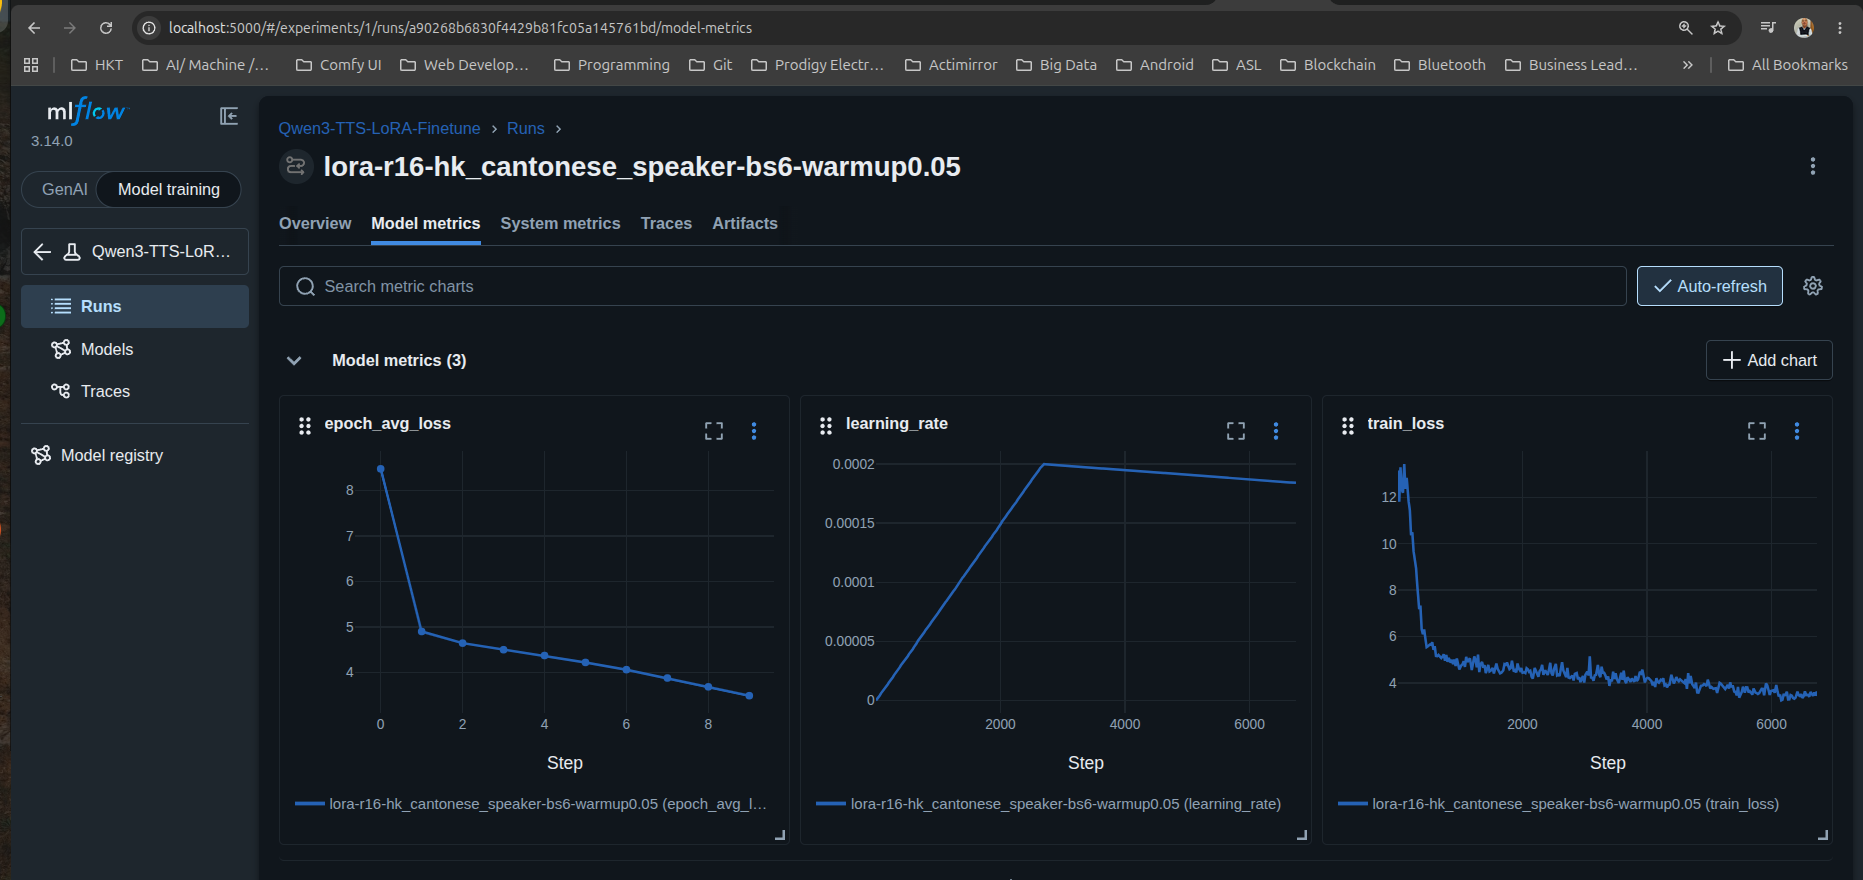

In [11]:
# upload final model to mlflow
import mlflow
# mlflow.log_artifacts("output/checkpoint-epoch-3", artifact_path="final_checkpoint")


/media/johnsonhk88/Big-Data-Disk/venv-qwen3-tts/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Test fine tuning

In [12]:
import torch
import soundfile as sf
from qwen_tts import Qwen3TTSModel

device = "cuda:0"
tts = Qwen3TTSModel.from_pretrained(
    # "./output/checkpoint-epoch-4",
    "./output_hk_cantonese_lora/checkpoint-epoch-0",
    # "./output_hk_cantonese_lora/final_merged",
    device_map=device,
    dtype=torch.bfloat16,
    # attn_implementation="flash_attention_2",
    attn_implementation= "sdpa", # no flash attention 
    
)




********
********
 


In [13]:
tts

In [14]:
# del tts

In [15]:
%%time
wavs, sr = tts.generate_custom_voice(
       # text="其實我真係有發覺，我係一個特別善於觀察別人情緒嘅人。",
       text = "飛機已經被grounded喇，因為typhoon signal已經升到No.8嚟啦。",
       # speaker="speaker_test",
       speaker="hk_cantonese_speaker",
  
      # 2. Use the base Chinese language token
      language="auto",#"chinese", 
       
      max_new_tokens=1500,    
      temperature=0.7,        
      top_p=0.9,
      top_k=50,
      
      # 3. CRITICAL: Disabled repetition penalty (Set to 1.0)
      repetition_penalty=1.0, 
      do_sample=True,
    
    # Optional but often helps quality
    # instruct="用自然的香港粤语语气说",  # if you want style control
    # instruct="用特别愤怒的语气说", # Omit if not needed.
)
sf.write("output_custom_voice.wav", wavs[0], sr)

Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.


CPU times: user 1min 24s, sys: 351 ms, total: 1min 24s
Wall time: 1min 24s


In [46]:
# %%time
# wavs, sr = tts.generate_voice_design(
#     text="其实我真的有发现，我是一个特别善于观察别人情绪的人。",
#     # language="Auto", # Pass `Auto` (or omit) for auto language adaptive; if the target language is known, set it explicitly.
#     speaker="speaker_test",
#     # language="yue" or "zh" or "Auto",   # Try "yue" for Cantonese if supported
    
#     # === Key parameters to reduce crash & speed up ===
#     max_new_tokens=1500,        # Limit total tokens (very important for long audio)
#     temperature=0.7,            # Lower = more stable, less random crash
#     top_p=0.9,
#     top_k=50,
#     repetition_penalty=1.2,     # Helps prevent repeating patterns that cause crash
#     do_sample=True,
    
#     # Optional but often helps quality
#     instruct="用自然的香港粤语语气说",  # if you want style control
#     # instruct="用特别愤怒的语气说", # Omit if not needed.
# )
# sf.write("output_custom_voice.wav", wavs[0], sr)

In [47]:
# Evaluation

##  Fix Eavlatuion : Speaker simiarlity skipped issue
Issues comes from the speechbrain library (the ECAPA-TDNN speaker encoder).
SpeechBrain is quite old and still calls torchaudio.list_audio_backends() internally.
This function was removed in torchaudio ≥ 2.4 (your PyTorch 2.10 comes with a very new torchaudio).
The script gracefully catches the error and disables speaker similarity (that's why you see N/A and sim_available = False).

In [42]:
%%time
!python evaluate_qwen3_tts.py \
  --checkpoint_dir "./output_hk_cantonese_lora/checkpoint-epoch-9" \
  --test_jsonl eval_prepared.jsonl \
  --language chinese \
  --speaker_name hk_cantonese_speaker \
  --skip_utmos \
  --max_samples 5


********
********
 
Loading fine-tuned model from: ./output_hk_cantonese_lora/checkpoint-epoch-9
✅ Loaded 5 test samples (new format with ref_audio)
🔄 Loading Whisper-large-v3-turbo (excellent for HK Cantonese)...
Device set to use cuda
🔄 Loading ECAPA-TDNN speaker encoder...
✅ Speaker encoder loaded!
✅ All models ready!
🚀 Starting evaluation with MANUAL WER/CER (custom tokenizer for code-mixing)...

Generating & Evaluating:   0%|                       | 0/5 [00:00<?, ?sample/s]Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.
`return_token_timestamps` is deprecated for WhisperFeatureExtractor and will be removed in Transformers v5. Use `return_attention_mask` instead, as the number of frames can be inferred from it.
Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.
Generating & Evaluating:  20%|███            | 1/5 [00:11<00:45, 11.3

In [46]:
resultPath = "./evaluation_results/results.csv"

In [47]:
resultDF = pd.read_csv(resultPath)
resultDF

,index,text,ref_text,pred_text,ref_audio,gen_audio,cer,wer,speaker_sim,utmos,...,wer_deletions,wer_insertions,wer_errors_(S+D+I),ref_chars_array,pred_chars_array,ref_chars,cer_substitutions,cer_deletions,cer_insertions,cer_errors_(S+D+I)
0,0,你可以去langham place嘅uniqlo買衫，質量好又價錢適中，真係好抵買。,你可以去langham place嘅uniqlo買衫，質量好又價錢適中，真係好抵買。,"ndash,ndash,ndash,ndash,ndash,ndash,ndash,ndas...",./audio/ref_voice/alienkevin.wav,evaluation_results/sample_000.wav,20.9524,61.6667,0.2166,NaN,...,0,364,370,"你, 可, 以, 去, l, a, n, g, h, a, m, , p, l, a, c...","n, d, a, s, h, ,, n, d, a, s, h, ,, n, d, a, s...",42,36,0,844,880
1,1,以customer為先，如果我哋success咁就是因為我哋put customer sat...,以customer為先，如果我哋success咁就是因為我哋put customer sat...,ndndndndndndndndndndndndndndndndndndndndndndnd...,./audio/ref_voice/alienkevin.wav,evaluation_results/sample_001.wav,8.6471,1.0000,0.2677,NaN,...,14,0,15,"以, c, u, s, t, o, m, e, r, 為, 先, ，, 如, 果, 我, 哋...","n, d, n, d, n, d, n, d, n, d, n, d, n, d, n, d...",102,98,0,784,882
2,2,我昨晚喺一間pizza place食咗一個loaded pepperoni pizza，邊個...,我昨晚喺一間pizza place食咗一個loaded pepperoni pizza，邊個...,ndndndndndndndndndndndndndndndndndndndndndndnd...,./audio/ref_voice/alienkevin.wav,evaluation_results/sample_002.wav,12.4366,1.0000,0.2575,NaN,...,10,0,11,"我, 昨, 晚, 喺, 一, 間, p, i, z, z, a, , p, l, a, c...","n, d, n, d, n, d, n, d, n, d, n, d, n, d, n, d...",71,68,0,815,883
3,3,嗰陣時嘅sunset真系無得輸，簡直係拍photo必定大賣一場。,嗰陣時嘅sunset真系無得輸，簡直係拍photo必定大賣一場。,你能给与好人的游客博博博博博博博博博博博博博博博博博博博博博博博博博博博博博博博博博博博博博...,./audio/ref_voice/alienkevin.wav,evaluation_results/sample_003.wav,7.0625,1.0000,0.3105,NaN,...,4,0,5,"嗰, 陣, 時, 嘅, s, u, n, s, e, t, 真, 系, 無, 得, 輸, ，...","你, 能, 给, 与, 好, 人, 的, 游, 客, 博, 博, 博, 博, 博, 博, 博...",32,32,0,194,226
4,4,我今年想試吓Cosplay喺Comic-Con，應該好exciting嘅，你有冇同我一齊嘅？,我今年想試吓Cosplay喺Comic-Con，應該好exciting嘅，你有冇同我一齊嘅？,"I don't know, I don't know, I don't know, I do...",./audio/ref_voice/alienkevin.wav,evaluation_results/sample_004.wav,6.5435,12.5714,0.2149,NaN,...,0,81,88,"我, 今, 年, 想, 試, 吓, C, o, s, p, l, a, y, 喺, C, o...","I, , d, o, n, ', t, , k, n, o, w, ,, , I, ...",46,40,0,261,301


Kernel Python: /media/johnsonhk88/Big-Data-Disk/venv-qwen3-tts/bin/python3.12
Found 10000 wav files in ./audio
Parquet exists: True


/media/johnsonhk88/Big-Data-Disk/qwen3-tts-hk-cantonese-finetune/Dataset-Cantonese-Training/cluster_speakers.py:58: UserWarning: Module 'speechbrain.pretrained' was deprecated, redirecting to 'speechbrain.inference'. Please update your script. This is a change from SpeechBrain 1.0. See: https://github.com/speechbrain/speechbrain/releases/tag/v1.0.0
  from speechbrain.pretrained import EncoderClassifier


Loading raw dataset from train-00000-of-00001.parquet...
Scanning audio folder for existing resampled files...
Found 10000 valid wav files in ./audio.
🔄 Loading ECAPA-TDNN speaker encoder...
🎙️ Extracting speaker embeddings...


100%|██████████| 10000/10000 [00:59<00:00, 167.51it/s]


Extracted 10000 speaker embeddings successfully.
🧩 Grouping similar voices together using Cosine Distance Clustering...
🎉 Discovered 1783 unique speakers in your dataset!
🔗 Creating speaker-matched reference mappings...
💾 Saving speaker-matched training data to train_raw.jsonl...
✅ Saved! train_raw.jsonl now has 10000 speaker-matched entries.

Top 10 speakers by audio count:
speaker_id
spk_015    1231
spk_178    1230
spk_193     311
spk_044     252
spk_177     245
spk_125     239
spk_010     218
spk_007     190
spk_051     174
spk_345     168
Name: count, dtype: int64


In [45]:
resultDF.columns

Index(['index', 'text', 'ref_text', 'pred_text', 'ref_audio', 'gen_audio',
       'cer', 'wer', 'speaker_sim', 'utmos', 'ref_words_array',
       'pred_words_array', 'ref_words', 'wer_substitutions', 'wer_deletions',
       'wer_insertions', 'wer_errors_(S+D+I)', 'ref_chars_array',
       'pred_chars_array', 'ref_chars', 'cer_substitutions', 'cer_deletions',
       'cer_insertions', 'cer_errors_(S+D+I)'],
      dtype='object')

In [1]:
# !python voice_clone_server.py